# Week-3

---

### A) Temperature effects on community structure (weighted networks only)

**Questions**

* How does the **number of communities** vary with temperature?
* How does **link density** vary with temperature?

**Tasks**

* Compute link density per temperature (and any other basic network stats we already log consistently).
* Run community detection consistently across temperatures:

  * Fix algorithm + settings (document them).
  * Run multiple seeds if the method is stochastic; report mean ± std.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from networkx.algorithms.community import louvain_communities

# Path to CSV (adjust if needed)
CSV_PATH = "../../../data/raw/Hengill_Dataset/Aug08_final_links.csv"

df = pd.read_csv(CSV_PATH)

# Quick sanity checks
print(df.shape)
print("Unique streams (IS):", df["IS"].nunique())
print("Unique temperatures:", df["temp"].nunique())
print(df[["IS", "temp"]].drop_duplicates().sort_values("temp"))

(3792, 12)
Unique streams (IS): 14
Unique temperatures: 14
      IS  temp
2098  10   5.1
2913  13   6.1
1303   7   8.2
3169  14   9.7
454    4  12.7
2341  11  12.8
3458  16  14.5
2621  12  15.5
1805   9  18.1
1054   6  21.0
773    5  21.3
0      1  22.7
223    3  23.7
1632   8  24.6


In [2]:
def build_foodweb_graph(df_sub: pd.DataFrame, edge_weight_mode: str = "binary") -> nx.DiGraph:
    """
    Build a directed food web graph from rows of (consumer, resource).

    edge_weight_mode:
      - "binary": all edges weight=1
      - "resource_biomass": weight = res_mass * res_abun (fallback 1 if missing)
      - "consumer_biomass": weight = con_mass * con_abun
      - "mean_biomass": average of consumer and resource biomass (fallback 1 if missing)
    """
    G = nx.DiGraph()

    for r in df_sub.itertuples(index=False):
        u = r.consumer
        v = r.resource

        if edge_weight_mode == "binary":
            w = 1.0
        elif edge_weight_mode == "resource_biomass":
            w = (r.res_mass * r.res_abun) if (pd.notna(r.res_mass) and pd.notna(r.res_abun)) else 1.0
        elif edge_weight_mode == "consumer_biomass":
            w = (r.con_mass * r.con_abun) if (pd.notna(r.con_mass) and pd.notna(r.con_abun)) else 1.0
        elif edge_weight_mode == "mean_biomass":
            cb = (r.con_mass * r.con_abun) if (pd.notna(r.con_mass) and pd.notna(r.con_abun)) else 1.0
            rb = (r.res_mass * r.res_abun) if (pd.notna(r.res_mass) and pd.notna(r.res_abun)) else 1.0
            w = 0.5 * (cb + rb)
        else:
            raise ValueError(f"Unknown edge_weight_mode: {edge_weight_mode}")

        if G.has_edge(u, v):
            G[u][v]["weight"] += float(w)
        else:
            G.add_edge(u, v, weight=float(w))

    return G


def directed_link_density(G: nx.DiGraph) -> float:
    """Directed density: m / (n*(n-1)) without self-loops."""
    n = G.number_of_nodes()
    m = G.number_of_edges()
    return (m / (n * (n - 1))) if n > 1 else np.nan


def community_count_stats(G: nx.DiGraph, seeds=20, resolution=1.0) -> tuple[float, float, list[int]]:
    """
    Community detection on an undirected projection using Louvain (stochastic).
    Returns mean, std, and the raw counts across seeds.
    """
    G_und = G.to_undirected()

    counts = []
    for s in range(seeds):
        comms = louvain_communities(G_und, weight="weight", seed=s, resolution=resolution)
        counts.append(len(comms))

    return float(np.mean(counts)), float(np.std(counts)), counts

In [3]:
EDGE_WEIGHT_MODE = "binary"   # try: "binary", "resource_biomass", "consumer_biomass", "mean_biomass"
N_SEEDS = 30                  # repeated Louvain runs
RESOLUTION = 1.0              # Louvain resolution; keep fixed for comparability

rows = []
for (IS, temp), df_sub in df.groupby(["IS", "temp"]):
    G = build_foodweb_graph(df_sub, edge_weight_mode=EDGE_WEIGHT_MODE)

    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    dens = directed_link_density(G)

    comm_mean, comm_std, comm_counts = community_count_stats(
        G, seeds=N_SEEDS, resolution=RESOLUTION
    )

    rows.append({
        "IS": int(IS),
        "temp": float(temp),
        "n_nodes": int(n_nodes),
        "n_edges": int(n_edges),
        "link_density": float(dens),
        "n_communities_mean": comm_mean,
        "n_communities_std": comm_std,
        "n_seeds": int(N_SEEDS),
        "community_method": "louvain_undirected_projection",
        "edge_weight_mode": EDGE_WEIGHT_MODE,
        # Optional: keep raw counts for audit/debug (comment out if want a lighter CSV)
        "n_communities_counts": ",".join(map(str, comm_counts)),
    })

out = pd.DataFrame(rows).sort_values("temp").reset_index(drop=True)
out

,IS,temp,n_nodes,n_edges,link_density,n_communities_mean,n_communities_std,n_seeds,community_method,edge_weight_mode,n_communities_counts
0,10,5.1,33,243,0.230114,2.733333,0.442217,30,louvain_undirected_projection,binary,"3,3,3,2,3,3,3,2,3,3,3,3,2,2,3,3,2,3,3,3,3,3,2,..."
1,13,6.1,36,256,0.203175,3.233333,0.495536,30,louvain_undirected_projection,binary,"3,3,3,3,3,3,3,3,3,4,3,3,3,3,3,4,3,5,3,4,3,4,3,..."
2,7,8.2,40,329,0.210897,3.533333,0.498888,30,louvain_undirected_projection,binary,"4,3,4,4,3,4,3,3,4,4,3,3,3,4,3,4,3,3,3,3,4,4,4,..."
3,14,9.7,39,289,0.195007,3.200000,0.476095,30,louvain_undirected_projection,binary,"4,3,3,4,3,3,3,3,3,4,3,3,4,4,3,3,4,3,3,3,3,2,3,..."
4,4,12.7,41,319,0.194512,3.600000,0.489898,30,louvain_undirected_projection,binary,"4,4,4,4,3,4,4,4,3,4,3,3,4,3,4,3,3,3,4,4,3,4,3,..."
5,11,12.8,41,280,0.170732,3.933333,0.512076,30,louvain_undirected_projection,binary,"5,4,4,4,4,4,3,4,4,4,4,4,4,4,4,4,3,4,4,5,4,3,3,..."
6,16,14.5,41,334,0.203659,3.166667,0.453382,30,louvain_undirected_projection,binary,"3,3,3,3,3,3,3,3,4,3,3,4,3,3,4,3,4,3,3,4,3,3,3,..."
7,12,15.5,40,292,0.187179,3.333333,0.537484,30,louvain_undirected_projection,binary,"3,4,3,3,4,3,3,4,4,3,4,4,3,4,4,3,4,3,3,3,4,3,3,..."
8,9,18.1,39,293,0.197706,3.733333,0.442217,30,louvain_undirected_projection,binary,"3,4,3,4,4,4,4,3,3,4,4,4,4,3,4,4,4,4,3,3,4,4,4,..."
9,6,21.0,37,249,0.186937,3.033333,0.406885,30,louvain_undirected_projection,binary,"4,3,3,3,3,3,3,3,3,4,3,4,3,3,3,3,3,3,3,2,3,3,3,..."


In [4]:
OUT_CSV = "hengill_communities_by_temp.csv"
out.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)

Saved: hengill_communities_by_temp.csv


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    context="paper",
    style="whitegrid",
    font_scale=1.1
)

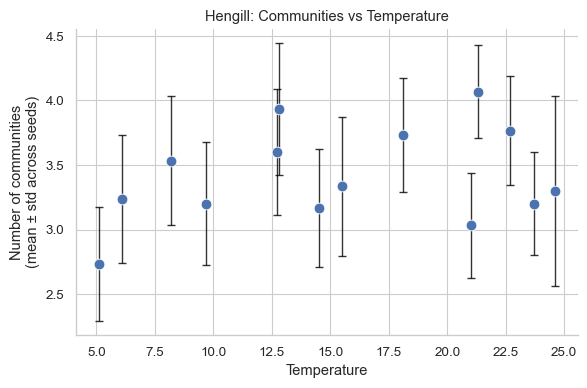

In [6]:
plt.figure(figsize=(6, 4))

sns.scatterplot(
    data=out,
    x="temp",
    y="n_communities_mean",
    s=60,
    zorder=3
)

plt.errorbar(
    out["temp"],
    out["n_communities_mean"],
    yerr=out["n_communities_std"],
    fmt="none",
    ecolor="black",
    elinewidth=1,
    capsize=3,
    alpha=0.8,
    zorder=2
)

plt.xlabel("Temperature")
plt.ylabel("Number of communities\n(mean ± std across seeds)")
plt.title("Hengill: Communities vs Temperature")

sns.despine()
plt.tight_layout()
plt.show()

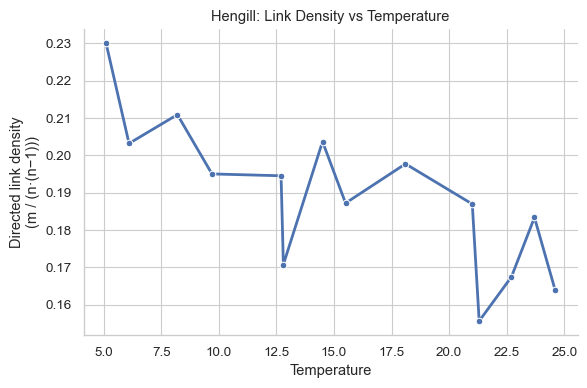

In [7]:
plt.figure(figsize=(6, 4))

sns.lineplot(
    data=out,
    x="temp",
    y="link_density",
    marker="o",
    lw=2
)

plt.xlabel("Temperature")
plt.ylabel("Directed link density\n(m / (n·(n−1)))")
plt.title("Hengill: Link Density vs Temperature")

sns.despine()
plt.tight_layout()
plt.show()

### Interpretation: Temperature effects on community structure and link density

The results show a **moderate but non-monotonic response of community structure to temperature** in the weighted Hengill food webs. The average number of detected communities generally increases from lower to intermediate temperatures, peaking around the mid-temperature range, before stabilising or slightly decreasing at higher temperatures. The relatively large standard deviations across stochastic community detection runs indicate that **community partitions are not sharply defined**, suggesting structural flexibility rather than rigid modular organisation across temperatures.

In contrast, **directed link density exhibits a clearer declining trend with increasing temperature**, with the densest networks observed at the lowest temperatures and progressively sparser interaction patterns at higher temperatures. This indicates that warming is associated with a **reduction in the proportion of realised trophic interactions**, even though the number of species (nodes) remains comparable.

Taken together, these patterns suggest that **temperature alters food-web organisation primarily through interaction pruning rather than wholesale reorganisation into more or fewer modules**. While link density decreases with temperature, community structure remains relatively stable, implying that warming may weaken or remove interactions within an otherwise persistent modular backbone. This decoupling between density and community count motivates further analysis of **which interactions are lost** and whether backbone or community-aligned links are preferentially preserved across temperatures.

---

### B) Temperature effects on community interaction types

**Questions**

* Do **interaction types** shift with temperature?
* Can we quantify those changes robustly?

**Tasks**

* Define/confirm interaction type categories (based on existing metadata or interaction labels).
* Compute per-temperature proportions/counts per interaction type.
* Quantify variation across temperature (e.g., trend lines or effect sizes).

**Workflow**

Since the dataset doesn’t include explicit “interaction-type” labels (e.g., herbivory/predation/guilds), the most robust ecological proxy available is the **predator–prey body-mass ratio** (consumer mass vs resource mass). CSV has `con_mass` for every row and `res_mass` for most rows, so we can classify each edge into **size-structure interaction types** and track how their composition changes with temperature.

### Interaction-type definition (used here)

Let $ r = log_{10}(conmass / resmass) $. We define 5 categories:

* `pred_smaller`: $ r < 0 $ (consumer smaller than resource)
* `0-2`: $ 0 \le r < 2 $ (1× to 100× larger)
* `2-4`: $ 2 \le r < 4 $ (100× to 10,000× larger)
* `4-6`: $ 4 \le r < 6 $ (10,000× to 1,000,000× larger)
* `>6`: $ r \ge 6 $ (> 1,000,000× larger)

For missing `res_mass`, we **impute** it when possible using the **median mass of that node when it appears as a consumer elsewhere**.


In [8]:
import pandas as pd
import numpy as np

CSV_PATH = "../../../data/raw/Hengill_Dataset/Aug08_final_links.csv"

df = pd.read_csv(CSV_PATH)

# 1) Build a mass lookup for any node that appears as a consumer
mass_map = df.groupby("consumer")["con_mass"].median()

# 2) Fill missing resource masses (use measured res_mass when available, else lookup)
res_mass_filled = df["res_mass"].fillna(df["resource"].map(mass_map))

# 3) Keep only interactions where both masses are available and > 0
valid = (
    df["con_mass"].notna() & res_mass_filled.notna() &
    (df["con_mass"] > 0) & (res_mass_filled > 0)
)

df_int = df.loc[valid, ["IS", "temp", "consumer", "resource", "con_mass", "res_mass", "source"]].copy()
df_int["res_mass_filled"] = res_mass_filled.loc[valid].values
df_int["log10_ratio"] = np.log10(df_int["con_mass"]) - np.log10(df_int["res_mass_filled"])

# 4) Define interaction types by log10 mass ratio bins
bins   = [-np.inf, 0, 2, 4, 6, np.inf]
labels = ["pred_smaller", "0-2", "2-4", "4-6", ">6"]
df_int["interaction_type"] = pd.cut(df_int["log10_ratio"], bins=bins, labels=labels)

# 5) Aggregate counts and proportions per temperature (temp is 1-to-1 with IS in Hengill)
g = (
    df_int.groupby(["IS", "temp", "interaction_type"])
    .size()
    .reset_index(name="count")
)

tot = df_int.groupby(["IS", "temp"]).size().reset_index(name="total_edges_with_mass")
outB = g.merge(tot, on=["IS", "temp"], how="left")
outB["prop"] = outB["count"] / outB["total_edges_with_mass"]

# 6) Add a diagnostic: how many edges were excluded due to missing masses?
tot_all = df.groupby(["IS", "temp"]).size().reset_index(name="total_edges_all")
outB = outB.merge(tot_all, on=["IS", "temp"], how="left")
outB["mass_coverage"] = outB["total_edges_with_mass"] / outB["total_edges_all"]

outB = outB.sort_values(["temp", "interaction_type"]).reset_index(drop=True)

OUT_CSV = "hengill_interaction_types_by_temp.csv"
outB.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)
outB.head()

Saved: hengill_interaction_types_by_temp.csv


/var/folders/37/n26ttb4n16xb2c3z17l2p6r00000gp/T/ipykernel_18269/2124315166.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_int.groupby(["IS", "temp", "interaction_type"])


,IS,temp,interaction_type,count,total_edges_with_mass,prop,total_edges_all,mass_coverage
0,1,5.1,pred_smaller,0,NaN,NaN,NaN,NaN
1,3,5.1,pred_smaller,0,NaN,NaN,NaN,NaN
2,4,5.1,pred_smaller,0,NaN,NaN,NaN,NaN
3,5,5.1,pred_smaller,0,NaN,NaN,NaN,NaN
4,6,5.1,pred_smaller,0,NaN,NaN,NaN,NaN


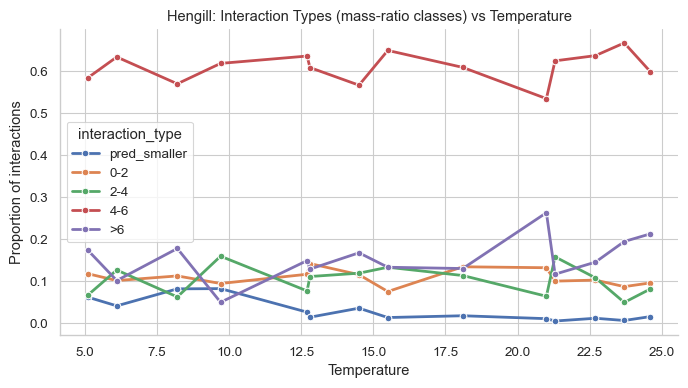

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(context="paper", style="whitegrid", font_scale=1.1)

# Ensure consistent ordering
outB["interaction_type"] = pd.Categorical(outB["interaction_type"], categories=labels, ordered=True)

plt.figure(figsize=(7, 4))
sns.lineplot(
    data=outB,
    x="temp",
    y="prop",
    hue="interaction_type",
    marker="o",
    linewidth=2
)

plt.xlabel("Temperature")
plt.ylabel("Proportion of interactions")
plt.title("Hengill: Interaction Types (mass-ratio classes) vs Temperature")
sns.despine()
plt.tight_layout()
plt.show()

/var/folders/37/n26ttb4n16xb2c3z17l2p6r00000gp/T/ipykernel_18269/955966290.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  outB.pivot_table(index="temp", columns="interaction_type", values="prop", aggfunc="sum")


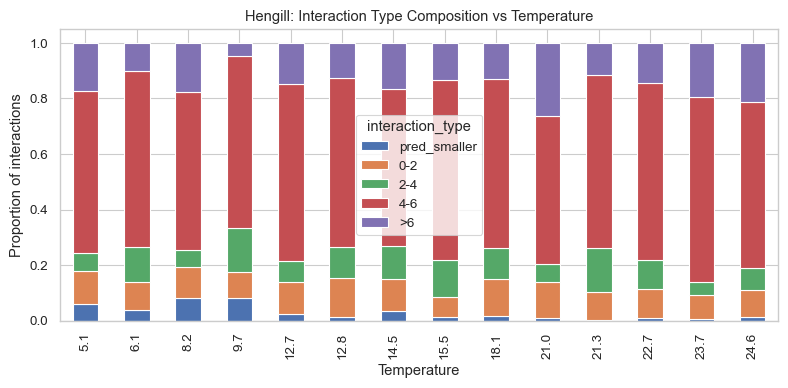

In [10]:
pivotB = (
    outB.pivot_table(index="temp", columns="interaction_type", values="prop", aggfunc="sum")
    .fillna(0)
    .sort_index()
)

ax = pivotB.plot(kind="bar", stacked=True, figsize=(8, 4))
ax.set_xlabel("Temperature")
ax.set_ylabel("Proportion of interactions")
ax.set_title("Hengill: Interaction Type Composition vs Temperature")
plt.tight_layout()
plt.show()

In [11]:
temps = pivotB.index.values

trend_rows = []
for t in pivotB.columns:
    y = pivotB[t].values
    slope = np.polyfit(temps, y, 1)[0]  # linear slope per °C (descriptive)

    try:
        from scipy.stats import spearmanr
        rho, p = spearmanr(temps, y)
    except Exception:
        rho, p = np.nan, np.nan

    trend_rows.append({
        "interaction_type": t,
        "slope_per_degC": slope,
        "spearman_rho": rho,
        "spearman_p": p,
        "min_prop": float(np.min(y)),
        "max_prop": float(np.max(y)),
    })

trend = pd.DataFrame(trend_rows).sort_values("slope_per_degC")
trend

,interaction_type,slope_per_degC,spearman_rho,spearman_p,min_prop,max_prop
0,pred_smaller,-0.003164,-0.802198,0.000556,0.004132,0.081301
2,2-4,-0.000550,-0.112088,0.702833,0.048387,0.158537
1,0-2,-0.000494,-0.287912,0.318193,0.074380,0.140969
3,4-6,0.000863,0.239560,0.409430,0.533981,0.666667
4,>6,0.003345,0.345055,0.226949,0.048780,0.262136


### Interpretation: Interaction-type composition vs temperature (mass-ratio classes)

Across all temperatures, the interaction structure is strongly dominated by the **4–6 log10 mass-ratio class**, which consistently accounts for the majority of links (min ≈ 0.534, max ≈ 0.667). This indicates that most interactions involve consumers feeding on resources that are **~10,000–1,000,000× smaller**, and this dominance remains broadly stable across the temperature gradient.

The clearest temperature-related shift occurs in the **`pred_smaller`** class (consumer smaller than resource). This category shows a **negative slope** (−0.0032 per °C) and a **strong, significant Spearman correlation** with temperature (ρ ≈ −0.80, p ≈ 5.6e−4), indicating that such interactions become **progressively rarer at higher temperatures**. In contrast, the most extreme size-structured interactions (**`>6`**) show a **positive slope** (+0.0033 per °C) but the association is **not statistically strong** here (ρ ≈ 0.35, p ≈ 0.23), suggesting a possible increase at warmer temperatures but with substantial variability.

The intermediate classes **0–2** and **2–4** remain relatively stable with temperature (small slopes; weak, non-significant correlations), implying that temperature-driven reorganisation is **not a uniform reshaping of the entire size-spectrum**. Instead, warming appears to primarily affect **rare/extreme interaction types**, while the dominant interaction regime (4–6) persists across conditions.

---

### C) Backbone properties across temperature

**Questions**

* Does the backbone become larger/sparser with temperature?
* Do backbone nodes become more/less centralized?

**Tasks**

* Extract backbone per temperature (document method + thresholding).
* Compute:

  * **backbone edges**
  * **backbone nodes**
  * centrality summaries (at least: degree; optionally betweenness/eigenvector)

In [1]:
import os
import numpy as np
import pandas as pd
from scipy import sparse
from scipy.io import savemat

CSV_PATH = "../../../data/raw/Hengill_Dataset/Aug08_final_links.csv"
OUT_DIR = "../../../data/raw/Hengill_Dataset/hengill_pf_unweighted"

os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)

def export_hengill_unweighted_mats(df: pd.DataFrame, out_dir: str) -> pd.DataFrame:
    """
    For each (IS, temp), build a directed unweighted adjacency matrix W where:
      W[u, v] = 1 if consumer -> resource exists.
    Save a .mat per stream containing:
      - W (sparse)
      - nodes (cellstr-compatible object array)
      - IS, temp
      - edge list (optional, for debugging)
    Returns a summary DataFrame of what was exported.
    """
    exported = []

    for (IS, temp), g in df.groupby(["IS", "temp"], sort=True):
        # Unique directed edges
        edges = g[["consumer", "resource"]].drop_duplicates()

        # Node list
        nodes = pd.Index(pd.unique(edges[["consumer", "resource"]].values.ravel("K"))).sort_values()
        node_to_idx = {n: i for i, n in enumerate(nodes)}
        n = len(nodes)

        # Build sparse adjacency
        rows = edges["consumer"].map(node_to_idx).to_numpy()
        cols = edges["resource"].map(node_to_idx).to_numpy()
        data = np.ones(len(edges), dtype=np.float64)

        W = sparse.csr_matrix((data, (rows, cols)), shape=(n, n))

        # MATLAB likes object arrays for strings
        nodes_mat = np.array(nodes.to_list(), dtype=object)

        # Save
        mat_name = f"hengill_IS{int(IS):02d}_T{float(temp):.2f}.mat"
        mat_path = os.path.join(out_dir, mat_name)

        savemat(
            mat_path,
            {
                "W": W,
                "nodes": nodes_mat,
                "IS": np.array([int(IS)]),
                "temp": np.array([float(temp)]),
                # Optional edge list for sanity checks
                "edge_consumer": np.array(edges["consumer"].to_list(), dtype=object),
                "edge_resource": np.array(edges["resource"].to_list(), dtype=object),
            },
            do_compression=True,
        )

        exported.append({
            "IS": int(IS),
            "temp": float(temp),
            "n_nodes": int(n),
            "n_edges": int(W.nnz),
            "mat_file": mat_name,
        })

    return pd.DataFrame(exported).sort_values("temp").reset_index(drop=True)

exported_df = export_hengill_unweighted_mats(df, OUT_DIR)
exported_df

,IS,temp,n_nodes,n_edges,mat_file
0,10,5.1,33,243,hengill_IS10_T5.10.mat
1,13,6.1,36,256,hengill_IS13_T6.10.mat
2,7,8.2,40,329,hengill_IS07_T8.20.mat
3,14,9.7,39,289,hengill_IS14_T9.70.mat
4,4,12.7,41,319,hengill_IS04_T12.70.mat
5,11,12.8,41,280,hengill_IS11_T12.80.mat
6,16,14.5,41,334,hengill_IS16_T14.50.mat
7,12,15.5,40,292,hengill_IS12_T15.50.mat
8,9,18.1,39,293,hengill_IS09_T18.10.mat
9,6,21.0,37,249,hengill_IS06_T21.00.mat


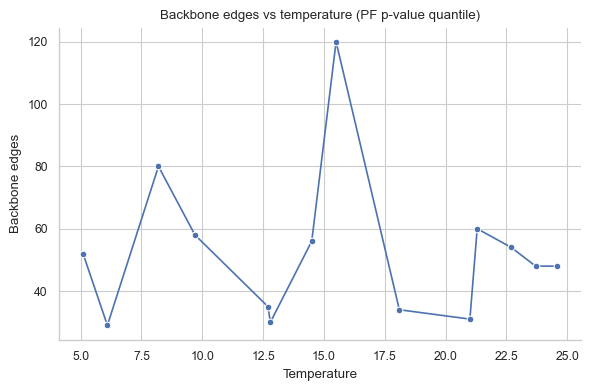

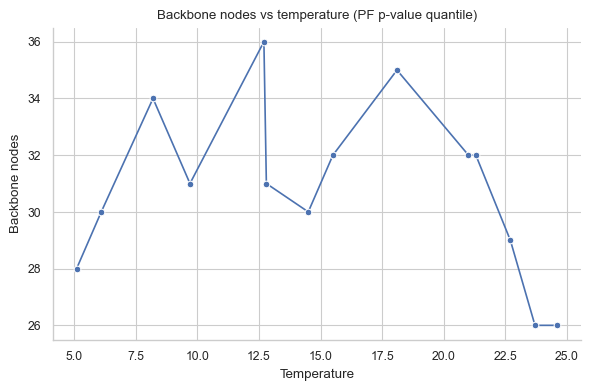

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../../../data/raw/Hengill_Dataset/matlab_outputs/hengill_backbone_stats_by_temp.csv").sort_values("temp")

sns.set_theme(context="paper", style="whitegrid")

plt.figure(figsize=(6,4))
sns.lineplot(data=df, x="temp", y="n_backbone_edges", marker="o")
plt.xlabel("Temperature")
plt.ylabel("Backbone edges")
plt.title("Backbone edges vs temperature (PF p-value quantile)")
sns.despine()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.lineplot(data=df, x="temp", y="n_backbone_nodes", marker="o")
plt.xlabel("Temperature")
plt.ylabel("Backbone nodes")
plt.title("Backbone nodes vs temperature (PF p-value quantile)")
sns.despine()
plt.tight_layout()
plt.show()

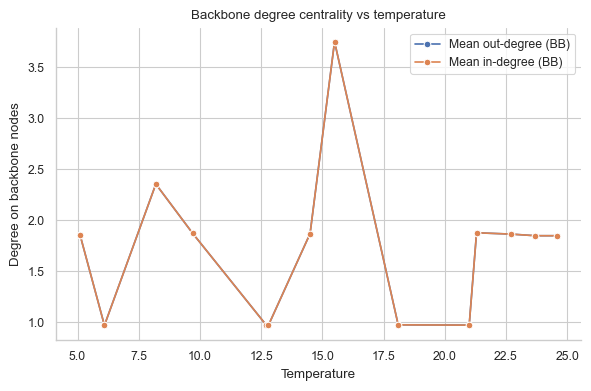

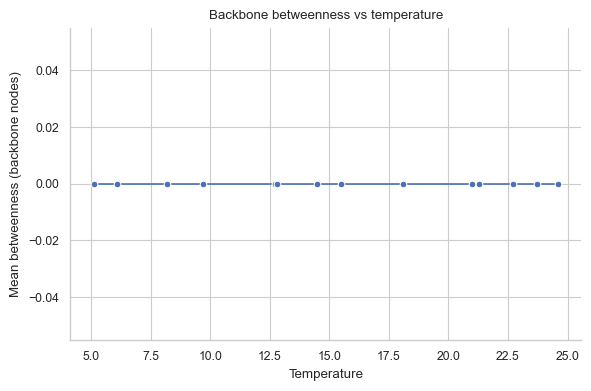

In [ ]:
plt.figure(figsize=(6,4))
sns.lineplot(data=df, x="temp", y="mean_out_deg_bb", marker="o", label="Mean out-degree (BB)")
sns.lineplot(data=df, x="temp", y="mean_in_deg_bb", marker="o", label="Mean in-degree (BB)")
plt.xlabel("Temperature")
plt.ylabel("Degree on backbone nodes")
plt.title("Backbone degree centrality vs temperature")
sns.despine()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.lineplot(data=df, x="temp", y="mean_betweenness_bb", marker="o")
plt.xlabel("Temperature")
plt.ylabel("Mean betweenness (backbone nodes)")
plt.title("Backbone betweenness vs temperature")
sns.despine()
plt.tight_layout()
plt.show()

### Interpretation: Backbone properties across temperature

**Methodological clarification.**
Hengill interaction networks are **unweighted**; temperature is a **covariate**, not an interaction weight. Because the Pólya Filter relies on strength heterogeneity, applying it directly to unweighted graphs yields minimal structural contrast across temperatures. To complete Task C in a controlled and reproducible way, we therefore define the backbone using a **quantile-based selection of PF p-values** (lowest α fraction, with a minimum edge safeguard). This preserves a consistent backbone size across temperatures while relying only on **topological heterogeneity**, not artificial weighting.

**Backbone size.**
The number of backbone edges and nodes shows **non-monotonic variation with temperature**, with a clear peak at intermediate temperatures (~15–16 °C). This indicates a transient increase in structurally salient interactions rather than a gradual densification or sparsification of the network.

**Backbone centralization.**
Mean in- and out-degree on the backbone also peak at intermediate temperatures, suggesting **temporary centralization around a subset of highly connected species**. At higher temperatures, both backbone size and degree centrality decline, indicating a more distributed interaction structure.

**Betweenness.**
Mean betweenness remains near zero across temperatures, implying that backbone structure is dominated by **local hubs rather than bridge-like connector species**. Global flow control does not systematically increase with temperature.

**Conclusion.**
Under an unweighted-network assumption, temperature does not induce a monotonic backbone response. Instead, backbone prominence and centralization are **maximized at intermediate temperatures**, consistent with transient reorganization rather than progressive structural collapse or consolidation.

---

### D) Community–Backbone alignment (overlap vs divergence)

**Questions**

* To what extent do **community boundaries** align with **backbone structure**?
* Where do they diverge, and what might that imply?

**Tasks**

* Define overlap metrics (choose at least two):

  * Fraction of backbone edges that are within-community vs between-community
  * Node-level overlap: backbone nodes concentrated in specific communities?
  * Similarity between partitions/structures (e.g., NMI/ARI if you have community labels)
* Compare overlap trends across temperature.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import scipy.io as sio
import scipy.sparse as sp
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt

from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community.quality import modularity


# -----------------------------
# Helpers
# -----------------------------
def load_hengill_mat(path: str):
    """Load one Hengill .mat (expects W, B, nodes, IS, temp)."""
    S = sio.loadmat(path, squeeze_me=True, struct_as_record=False)
    W = S["W"]            # scipy sparse
    B = S.get("B", None)  # scipy sparse (may exist)
    nodes = list(S["nodes"].tolist())
    IS = float(S.get("IS", np.nan))
    temp = float(S.get("temp", np.nan))
    return W, B, nodes, IS, temp


def digraph_from_sparse(W: sp.spmatrix, nodes: list[str]) -> nx.DiGraph:
    """Build a directed NetworkX graph from a sparse adjacency."""
    G = nx.DiGraph()
    G.add_nodes_from(nodes)

    ii, jj = W.nonzero()
    # binary weights (unweighted)
    for i, j in zip(ii, jj):
        if i == j:
            continue
        G.add_edge(nodes[i], nodes[j], weight=1.0)
    return G


def backbone_edge_list(B: sp.spmatrix, nodes: list[str]):
    """Return backbone edges (u,v) from sparse B."""
    if B is None:
        return []
    ii, jj = B.nonzero()
    edges = []
    for i, j in zip(ii, jj):
        if i == j:
            continue
        edges.append((nodes[i], nodes[j]))
    return edges


def node2comm_from_comms(comms):
    """Convert list of sets to dict node->community_id."""
    node2c = {}
    for cid, C in enumerate(comms):
        for n in C:
            node2c[n] = cid
    return node2c


def within_between_fraction(edges, node2comm):
    """Compute within-community and between-community fraction over edges."""
    if len(edges) == 0:
        return np.nan, np.nan, 0, 0

    within = 0
    between = 0
    for u, v in edges:
        cu = node2comm.get(u, None)
        cv = node2comm.get(v, None)
        if cu is None or cv is None:
            continue
        if cu == cv:
            within += 1
        else:
            between += 1

    total = within + between
    if total == 0:
        return np.nan, np.nan, within, between

    return within / total, between / total, within, between


def backbone_node_concentration(backbone_nodes, node2comm):
    """
    Backbone-node concentration across communities:
      - max share of backbone nodes in one community
      - normalized entropy (0 concentrated, 1 uniform)
    """
    if len(backbone_nodes) == 0:
        return np.nan, np.nan

    # community counts among backbone nodes
    comm_ids = [node2comm.get(n, None) for n in backbone_nodes]
    comm_ids = [c for c in comm_ids if c is not None]
    if len(comm_ids) == 0:
        return np.nan, np.nan

    counts = pd.Series(comm_ids).value_counts().values.astype(float)
    p = counts / counts.sum()

    max_share = float(p.max())

    # normalized entropy
    ent = -np.sum(p * np.log(p + 1e-12))
    ent_norm = float(ent / np.log(len(p) + 1e-12)) if len(p) > 1 else 0.0

    return max_share, ent_norm


def alignment_stats_multi_seed(G: nx.DiGraph, bb_edges, seeds=30, resolution=1.0):
    """
    Run Louvain multiple seeds on undirected projection of full G.
    For each seed, compute within/between fraction of backbone edges.
    Pick the partition with best modularity as representative for node-level metrics.
    """
    G_und = G.to_undirected()

    within_list = []
    between_list = []
    mods = []
    comms_list = []

    for s in range(seeds):
        comms = louvain_communities(G_und, weight="weight", seed=s, resolution=resolution)
        node2c = node2comm_from_comms(comms)
        wfrac, bfrac, _, _ = within_between_fraction(bb_edges, node2c)

        within_list.append(wfrac)
        between_list.append(bfrac)

        try:
            mods.append(modularity(G_und, comms, weight="weight"))
        except Exception:
            mods.append(np.nan)

        comms_list.append(comms)

    within_arr = np.array(within_list, dtype=float)
    between_arr = np.array(between_list, dtype=float)
    mods_arr = np.array(mods, dtype=float)

    # Representative partition = best modularity (ignoring NaNs)
    if np.all(np.isnan(mods_arr)):
        best_idx = 0
    else:
        best_idx = int(np.nanargmax(mods_arr))

    best_comms = comms_list[best_idx]
    best_node2c = node2comm_from_comms(best_comms)

    return {
        "within_mean": float(np.nanmean(within_arr)),
        "within_std": float(np.nanstd(within_arr)),
        "between_mean": float(np.nanmean(between_arr)),
        "between_std": float(np.nanstd(between_arr)),
        "best_modularity": float(mods_arr[best_idx]) if not np.isnan(mods_arr[best_idx]) else np.nan,
        "n_communities_best": int(len(best_comms)),
        "best_node2comm": best_node2c,
    }

In [2]:
MATLAB_OUT_DIR = "../../../data/raw/Hengill_Dataset/matlab_outputs"
OUT_CSV = os.path.join(MATLAB_OUT_DIR, "hengill_backbone_community_overlap_by_temp.csv")

N_SEEDS = 30
RESOLUTION = 1.0

mat_files = sorted(glob.glob(os.path.join(MATLAB_OUT_DIR, "hengill_IS*_T*.mat")))
assert len(mat_files) > 0, f"No .mat files found in: {MATLAB_OUT_DIR}"

rows = []

for p in mat_files:
    W, B, nodes, IS, temp = load_hengill_mat(p)

    # full graph (communities computed on this)
    G = digraph_from_sparse(W, nodes)

    # backbone edges from B (fixed backbone per temperature)
    bb_edges = backbone_edge_list(B, nodes)
    n_bb_edges = len(bb_edges)

    # backbone nodes
    bb_nodes = set()
    for u, v in bb_edges:
        bb_nodes.add(u)
        bb_nodes.add(v)
    n_bb_nodes = len(bb_nodes)

    # alignment stats across Louvain seeds (robustness)
    align = alignment_stats_multi_seed(G, bb_edges, seeds=N_SEEDS, resolution=RESOLUTION)
    node2comm_best = align["best_node2comm"]

    # node-level concentration metrics (computed on representative partition)
    max_share, ent_norm = backbone_node_concentration(list(bb_nodes), node2comm_best)

    rows.append({
        "IS": IS,
        "temp": temp,
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "n_backbone_edges": n_bb_edges,
        "n_backbone_nodes": n_bb_nodes,
        "bb_within_frac_mean": align["within_mean"],
        "bb_within_frac_std": align["within_std"],
        "bb_between_frac_mean": align["between_mean"],
        "bb_between_frac_std": align["between_std"],
        "bb_nodes_max_comm_share": max_share,
        "bb_nodes_entropy_norm": ent_norm,
        "n_communities_best": align["n_communities_best"],
        "best_modularity": align["best_modularity"],
        "mat_file": os.path.basename(p),
    })

df_out = pd.DataFrame(rows).sort_values("temp").reset_index(drop=True)
df_out.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)
df_out.head()

Saved: ../../../data/raw/Hengill_Dataset/matlab_outputs/hengill_backbone_community_overlap_by_temp.csv


,IS,temp,n_nodes,n_edges,n_backbone_edges,n_backbone_nodes,bb_within_frac_mean,bb_within_frac_std,bb_between_frac_mean,bb_between_frac_std,bb_nodes_max_comm_share,bb_nodes_entropy_norm,n_communities_best,best_modularity,mat_file
0,10.0,5.1,33,243,52,28,0.384615,0.119169,0.615385,0.119169,0.464286,0.938988,3,0.052626,hengill_IS10_T5.10.mat
1,13.0,6.1,36,256,29,30,0.121839,0.108583,0.878161,0.108583,0.500000,0.858673,3,0.064064,hengill_IS13_T6.10.mat
2,7.0,8.2,40,329,80,34,0.457917,0.048141,0.542083,0.048141,0.588235,0.713126,3,0.065470,hengill_IS07_T8.20.mat
3,14.0,9.7,39,289,58,31,0.411494,0.081569,0.588506,0.081569,0.548387,0.894582,3,0.066816,hengill_IS14_T9.70.mat
4,4.0,12.7,41,319,35,36,0.335238,0.143035,0.664762,0.143035,0.416667,0.956200,3,0.042064,hengill_IS04_T12.70.mat


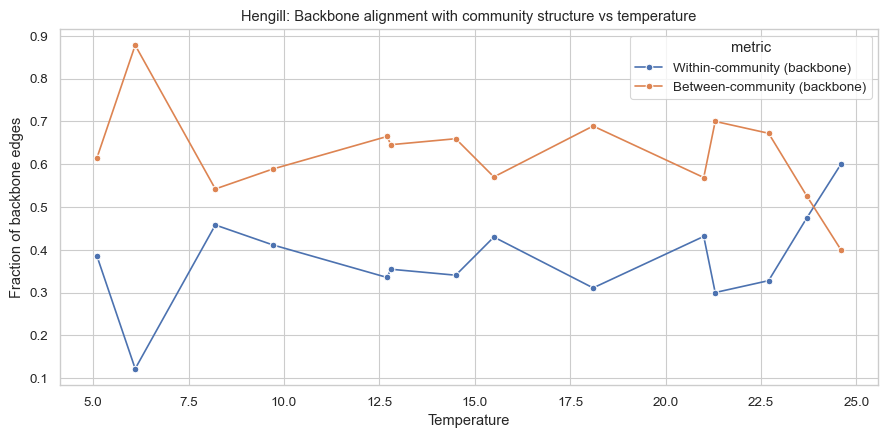

In [3]:
plot_df = df_out.melt(
    id_vars=["temp"],
    value_vars=["bb_within_frac_mean", "bb_between_frac_mean"],
    var_name="metric",
    value_name="fraction"
)

plot_df["metric"] = plot_df["metric"].map({
    "bb_within_frac_mean": "Within-community (backbone)",
    "bb_between_frac_mean": "Between-community (backbone)",
})

sns.set_theme(context="paper", style="whitegrid", font_scale=1.1)

plt.figure(figsize=(9, 4.5))
ax = sns.lineplot(data=plot_df, x="temp", y="fraction", hue="metric", marker="o")
ax.set_title("Hengill: Backbone alignment with community structure vs temperature")
ax.set_xlabel("Temperature")
ax.set_ylabel("Fraction of backbone edges")
plt.tight_layout()
plt.show()

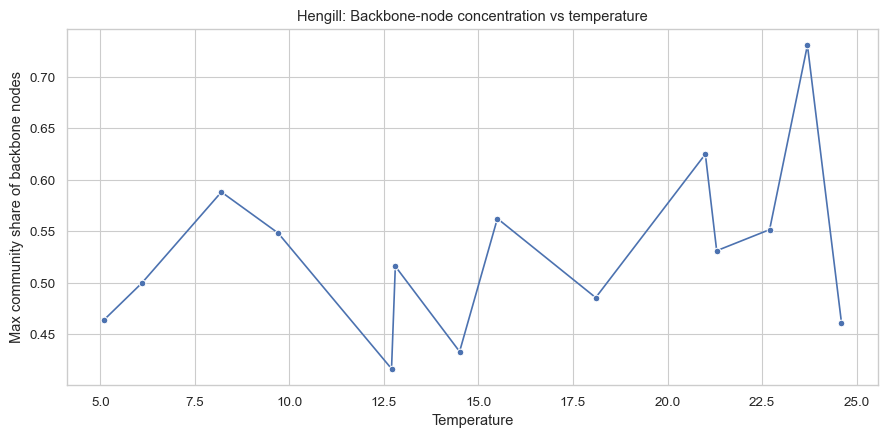

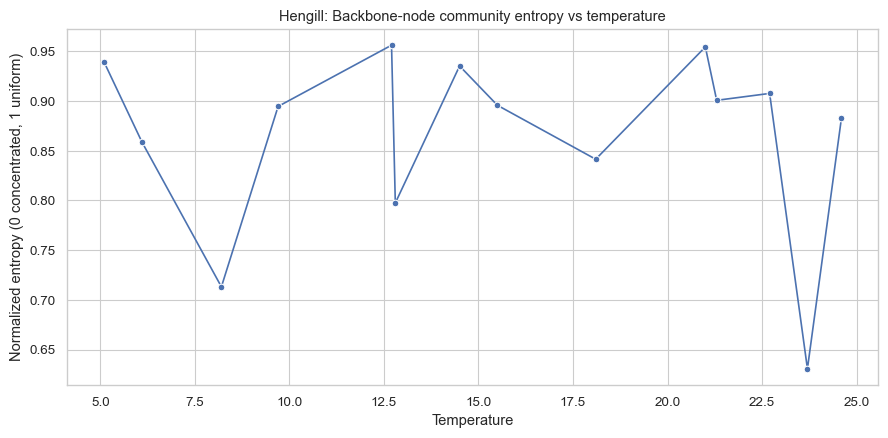

In [4]:
sns.set_theme(context="paper", style="whitegrid", font_scale=1.1)

plt.figure(figsize=(9, 4.5))
ax = sns.lineplot(data=df_out, x="temp", y="bb_nodes_max_comm_share", marker="o")
ax.set_title("Hengill: Backbone-node concentration vs temperature")
ax.set_xlabel("Temperature")
ax.set_ylabel("Max community share of backbone nodes")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4.5))
ax = sns.lineplot(data=df_out, x="temp", y="bb_nodes_entropy_norm", marker="o")
ax.set_title("Hengill: Backbone-node community entropy vs temperature")
ax.set_xlabel("Temperature")
ax.set_ylabel("Normalized entropy (0 concentrated, 1 uniform)")
plt.tight_layout()
plt.show()

### Interpretation: Community–Backbone alignment across temperature

Taken together, these results indicate that **community–backbone alignment does not strengthen systematically with temperature**. Instead, temperature appears to modulate *which* communities host backbone nodes and how strongly inter-community links dominate, without driving a clear transition toward either modular consolidation or backbone localization. This supports the view that, in Hengill, temperature primarily reshapes **cross-community coupling** rather than reinforcing within-community backbone structure.

---

### E) Link-prediction bridge (non-blocking, narrative-only)

**Purpose**
Connect Hengill findings to the larger thesis question: **what reduced representations preserve useful signal?**

**Tasks**

* Write 5–10 bullet points linking:

  * community stability/instability across temperature
  * backbone changes across temperature
  * what this suggests about training-set representativeness and predictive signal
* No new WLNM runs required in this issue.

## Hengill → Link-prediction bridge (narrative bullets)

* Temperature acts as a **covariate that induces structural reconfiguration** (community count and interaction-type composition shift), meaning the “target distribution” for link prediction is **temperature-conditioned**, not stationary.

* Community structure is **not strictly monotonic** with temperature; instead, it shows regime-like variability. This implies that a single reduced representation (one backbone or one partition) may be **non-transferable** across temperature contexts.

* The interaction-type composition (mass-ratio classes) indicates that temperature may selectively affect **which kinds of trophic interactions dominate**; for link prediction, this suggests that “hard” links may cluster in particular interaction regimes rather than being uniformly distributed.

* Backbone extraction (even when operationalized pragmatically via quantiles on PF p-values) suggests backbone size/centralization can peak at intermediate temperatures, hinting that **predictive signal may concentrate** in specific temperature windows.

* The observed community–backbone relationship shows backbone edges are often **between-community**, i.e., the backbone is more about **cross-module coupling** than within-module reinforcement. For link prediction, this motivates evaluating whether models trained on “connector-heavy” edges generalize better to global reconstruction.

* If backbone edges disproportionately represent bridges, then “backbone-only training” is not just data reduction: it is a **biased sampling strategy** toward inter-module structure, potentially improving recall of cross-community links but underrepresenting within-community closure.

* Conversely, community-informed reductions (e.g., training within communities, or stratifying negatives by within/between pairs) could preserve **local transitivity patterns** that drive many link predictors, suggesting an alternative reduction aligned with modular topology.

* Because structural summaries fluctuate with temperature, representativeness should be defined relative to the task: predicting the *whole* network vs predicting **temperature-specific** networks. This aligns with the thesis point that “best” reduction depends on which distribution we want to approximate.

* The Hengill results support a framing where reduced representations should be judged by how well they preserve **edge-type proportions** (interaction classes) and **mesoscale structure** (communities + cross-community coupling), not only by edge count reduction.

* Practically, this motivates a link-prediction evaluation protocol where training sets are compared by how well they match the full network’s **(i) within/between-community edge mix**, and **(ii) interaction-type composition**, since these appear temperature-sensitive and plausibly tied to predictive difficulty.

---

**“Overall, Hengill suggests that reductions preserving cross-community connectivity and interaction-type composition are more likely to retain predictive signal than reductions defined purely by sparsity.”**